# Padronização, consolidação e levantamentos — avaliações de foco/concisão

Este notebook fica na mesma pasta dos arquivos `.xlsx` de avaliação. Ao rodar:

1. **Padroniza** os nomes dos arquivos para `{concurso}_batch_{NN}_avaliacao_foco_concisao.xlsx`. É idempotente: rodar de novo não quebra nem renomeia o que já está padrão.
2. **Consolida** todos os arquivos em um único DataFrame.
3. **Valida** o que foi carregado (linhas por arquivo, scores, modelos).
4. Gera **levantamentos** para o TCC.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Tokenizador: tiktoken (cl100k_base) é usado como proxy universal.
# Se nao estiver disponivel, caimos numa contagem por palavras com fator de ajuste.
try:
    import tiktoken
    _ENC = tiktoken.get_encoding('cl100k_base')
    def _count_tokens(text: str) -> int:
        if not isinstance(text, str) or not text:
            return 0
        return len(_ENC.encode(text))
    _TOKENIZER = 'tiktoken/cl100k_base'
except Exception as _e:
    def _count_tokens(text: str) -> int:
        # Aproximacao: 1 token ~ 0.75 palavras em portugues (heuristica conservadora)
        if not isinstance(text, str) or not text:
            return 0
        return int(round(len(text.split()) / 0.75))
    _TOKENIZER = f'fallback/palavras (tiktoken indisponivel: {type(_e).__name__})'

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda v: f'{v:.3f}' if isinstance(v, float) else str(v))

# Tema visual unificado para todas as figuras do TCC
sns.set_theme(style='whitegrid', context='paper', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

NOTEBOOK_DIR = Path.cwd()
print(f'Pasta de trabalho: {NOTEBOOK_DIR}')
print(f'Arquivos .xlsx na pasta: {len(list(NOTEBOOK_DIR.glob("*.xlsx")))}')
print(f'Tokenizador: {_TOKENIZER}')

Pasta de trabalho: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/concisao
Arquivos .xlsx na pasta: 16
Tokenizador: tiktoken/cl100k_base


## 1. Padronização de nomes

Regras:
- O parser reconhece o concurso (`bndes`, `petrobras`, `cvm`) e o número do batch a partir de qualquer variação de nome.
- Alvo: `{concurso}_batch_{NN}_avaliacao_foco_concisao.xlsx` (batch com dois dígitos).
- Se o arquivo já está no formato alvo, é deixado em paz.
- Se renomear causaria sobrescrever um arquivo existente, o conflito é reportado e nada é renomeado.
- Arquivos que o parser não reconhece também são reportados (sem mexer).

In [2]:
CONCURSOS = ('bndes', 'petrobras', 'cvm')
TARGET_SUFFIX = 'avaliacao_foco_concisao'
SEP = r'(?:^|[_\-\.])'

def parse_filename(name: str):
    """Extrai (concurso, batch_num) de qualquer variação. Retorna None se não reconhecer."""
    stem = Path(name).stem.lower()
    concurso = next(
        (c for c in CONCURSOS if re.search(rf'{SEP}{c}(?=[_\-\.]|$)', stem)),
        None,
    )
    if not concurso:
        return None
    m = re.search(r'batch[_\-]?(\d+)', stem)
    if not m:
        return None
    return concurso, int(m.group(1))

def standard_name(concurso: str, batch_num: int) -> str:
    return f'{concurso}_batch_{batch_num:02d}_{TARGET_SUFFIX}.xlsx'

def padronizar_nomes(folder: Path, dry_run: bool = False):
    renames, skipped, conflicts, unparsed = [], [], [], []
    for f in sorted(folder.glob('*.xlsx')):
        parsed = parse_filename(f.name)
        if not parsed:
            unparsed.append(f.name)
            continue
        new_name = standard_name(*parsed)
        if f.name == new_name:
            skipped.append(f.name)
            continue
        target = f.parent / new_name
        if target.exists():
            conflicts.append((f.name, new_name))
            continue
        if not dry_run:
            f.rename(target)
        renames.append((f.name, new_name))
    return renames, skipped, conflicts, unparsed

In [3]:
# Rodar a padronização. Troque dry_run=True para apenas simular.
renames, skipped, conflicts, unparsed = padronizar_nomes(NOTEBOOK_DIR, dry_run=False)

print(f'Renomeados: {len(renames)}')
for old, new in renames:
    print(f'  {old}  ->  {new}')

print(f'\nJa no padrao (mantidos): {len(skipped)}')
for name in skipped:
    print(f'  {name}')

if conflicts:
    print(f'\nCONFLITOS (alvo ja existe, nada foi feito): {len(conflicts)}')
    for old, new in conflicts:
        print(f'  {old}  ->  {new}')

if unparsed:
    print(f'\nNao reconhecidos pelo parser: {len(unparsed)}')
    for name in unparsed:
        print(f'  {name}')

Renomeados: 0

Ja no padrao (mantidos): 15
  bndes_batch_01_avaliacao_foco_concisao.xlsx
  bndes_batch_02_avaliacao_foco_concisao.xlsx
  bndes_batch_03_avaliacao_foco_concisao.xlsx
  bndes_batch_04_avaliacao_foco_concisao.xlsx
  bndes_batch_05_avaliacao_foco_concisao.xlsx
  cvm_batch_01_avaliacao_foco_concisao.xlsx
  cvm_batch_02_avaliacao_foco_concisao.xlsx
  cvm_batch_03_avaliacao_foco_concisao.xlsx
  cvm_batch_04_avaliacao_foco_concisao.xlsx
  cvm_batch_05_avaliacao_foco_concisao.xlsx
  petrobras_batch_01_avaliacao_foco_concisao.xlsx
  petrobras_batch_02_avaliacao_foco_concisao.xlsx
  petrobras_batch_03_avaliacao_foco_concisao.xlsx
  petrobras_batch_04_avaliacao_foco_concisao.xlsx
  petrobras_batch_05_avaliacao_foco_concisao.xlsx

Nao reconhecidos pelo parser: 1
  consolidado_foco_concisao.xlsx


## 2. Consolidação em um DataFrame único

Lê todos os arquivos no padrão, anexa colunas `concurso`, `batch` e `arquivo` de origem.

In [4]:
ESPERADAS = ['id', 'pergunta', 'modelo', 'resposta', 'score', 'justificativa']

def consolidar(folder: Path) -> pd.DataFrame:
    dfs = []
    avisos = []
    for f in sorted(folder.glob(f'*_{TARGET_SUFFIX}.xlsx')):
        parsed = parse_filename(f.name)
        if not parsed:
            continue
        concurso, batch_num = parsed
        df_ = pd.read_excel(f)
        faltando = [c for c in ESPERADAS if c not in df_.columns]
        if faltando:
            avisos.append(f'{f.name}: faltam colunas {faltando}')
        df_['concurso'] = concurso
        df_['batch'] = batch_num
        df_['arquivo'] = f.name
        dfs.append(df_)
    if not dfs:
        return pd.DataFrame(), avisos
    return pd.concat(dfs, ignore_index=True), avisos

df, avisos = consolidar(NOTEBOOK_DIR)
print(f'Total de linhas: {len(df)}')
print(f'Colunas: {list(df.columns)}')
if avisos:
    print('\nAvisos de schema:')
    for a in avisos:
        print(f'  {a}')
df.head()

Total de linhas: 1650
Colunas: ['id', 'pergunta', 'modelo', 'resposta', 'score', 'justificativa', 'concurso', 'batch', 'arquivo']


,id,pergunta,modelo,resposta,score,justificativa,concurso,batch,arquivo
0,1,Qual o período de inscrição para o concurso BNDES?,claude-haiku-4-5,**Período de inscrição do BNDES (01/2024):**\n\nAs inscrições foram realizad...,1,respondeu o período com aviso útil e volume razoável,bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
1,1,Qual o período de inscrição para o concurso BNDES?,claude-opus-4-7,O período de inscrição para o concurso BNDES (Edital 01/2024) foi:\n\n📅 **De...,0,"despejou isenção, resultado final e oferta sem pedir",bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
2,1,Qual o período de inscrição para o concurso BNDES?,claude-sonnet-4-6,Aqui estão as informações sobre o período de inscrição do concurso BNDES 01/...,0,"despejou tabela, taxa, prova e resultado sem pedir",bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
3,1,Qual o período de inscrição para o concurso BNDES?,deepseek-v4-flash,O período de inscrição para o concurso BNDES (Edital 01/2024) foi **das 10h ...,1,respondeu o período com poucos detalhes extras,bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
4,1,Qual o período de inscrição para o concurso BNDES?,deepseek-v4-pro,O período de inscrição para o concurso do BNDES (Edital 01/2024) foi **das 1...,0,acrescentou isenção e taxa de forma desproporcional,bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx


## 3. Validação

Confere se cada arquivo tem o número esperado de linhas (10 perguntas × 11 modelos = 110), se os scores estão no domínio {0, 1}, e quais modelos aparecem.

In [5]:
print('Linhas por arquivo (esperado: 110):')
contagem = (df.groupby(['concurso', 'batch'])
              .size()
              .reset_index(name='n_linhas')
              .sort_values(['concurso', 'batch']))
contagem['ok'] = contagem['n_linhas'] == 110
print(contagem.to_string(index=False))

Linhas por arquivo (esperado: 110):
 concurso  batch  n_linhas   ok
    bndes      1       110 True
    bndes      2       110 True
    bndes      3       110 True
    bndes      4       110 True
    bndes      5       110 True
      cvm      1       110 True
      cvm      2       110 True
      cvm      3       110 True
      cvm      4       110 True
      cvm      5       110 True
petrobras      1       110 True
petrobras      2       110 True
petrobras      3       110 True
petrobras      4       110 True
petrobras      5       110 True


In [6]:
print('Valores de score encontrados:')
print(df['score'].value_counts(dropna=False))

if df['score'].isna().any():
    print(f'\n{df["score"].isna().sum()} linhas com score nulo')

Valores de score encontrados:
score
1    1099
0     551
Name: count, dtype: int64


In [7]:
print(f'Modelos distintos: {df["modelo"].nunique()}')
print('\nContagem por modelo:')
print(df['modelo'].value_counts().to_string())

Modelos distintos: 11

Contagem por modelo:
modelo
claude-haiku-4-5     150
claude-opus-4-7      150
claude-sonnet-4-6    150
deepseek-v4-flash    150
deepseek-v4-pro      150
gpt-4o-mini          150
gpt-5.4              150
gpt-5.4-mini         150
gpt-5.5              150
chatgpt              150
claude_chat          150


In [8]:
# Quais batches estao presentes por concurso
matriz = (df.groupby(['concurso', 'batch']).size()
            .unstack(fill_value=0)
            .astype(int))
print('Linhas por concurso x batch:')
print(matriz)

Linhas por concurso x batch:
batch        1    2    3    4    5
concurso                          
bndes      110  110  110  110  110
cvm        110  110  110  110  110
petrobras  110  110  110  110  110


## 4. Levantamentos para o TCC

A métrica é binária: `score = 1` → resposta focada; `score = 0` → resposta verbosa demais.  
A média do score equivale à **taxa de respostas focadas**.

### 4.1 Visão geral

In [9]:
total = len(df)
focadas = int(df['score'].sum())
verbosas = total - focadas
taxa = df['score'].mean()

print(f'Total de avaliacoes: {total}')
print(f'Respostas focadas (score=1): {focadas} ({focadas/total:.1%})')
print(f'Respostas verbosas (score=0): {verbosas} ({verbosas/total:.1%})')
print(f'Taxa media de foco: {taxa:.3f}')
print(f'\nConcursos cobertos: {sorted(df["concurso"].unique())}')
print(f'Modelos avaliados: {df["modelo"].nunique()}')

Total de avaliacoes: 1650
Respostas focadas (score=1): 1099 (66.6%)
Respostas verbosas (score=0): 551 (33.4%)
Taxa media de foco: 0.666

Concursos cobertos: ['bndes', 'cvm', 'petrobras']
Modelos avaliados: 11


### 4.2 Ranking de modelos por foco/concisão

In [10]:
por_modelo = (df.groupby('modelo')['score']
                .agg(taxa_foco='mean', n_focadas='sum', n_total='count')
                .sort_values('taxa_foco', ascending=False))
por_modelo['n_verbosas'] = por_modelo['n_total'] - por_modelo['n_focadas']
por_modelo[['taxa_foco', 'n_focadas', 'n_verbosas', 'n_total']]

,taxa_foco,n_focadas,n_verbosas,n_total
modelo,,,,
chatgpt,1.000,150,0,150
gpt-5.4-mini,0.993,149,1,150
gpt-5.4,0.973,146,4,150
gpt-5.5,0.973,146,4,150
gpt-4o-mini,0.887,133,17,150
deepseek-v4-flash,0.560,84,66,150
claude-haiku-4-5,0.533,80,70,150
claude-opus-4-7,0.487,73,77,150
deepseek-v4-pro,0.473,71,79,150


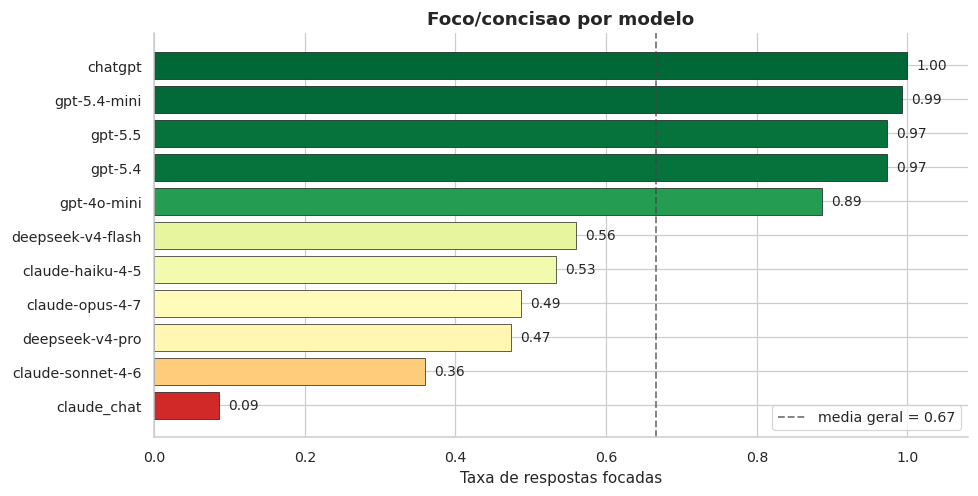

In [11]:
# Versao melhorada do grafico de barras com cores graduadas, anotacoes e linha de media.
por_modelo_sorted = por_modelo['taxa_foco'].sort_values()
fig, ax = plt.subplots(figsize=(9, max(4.5, 0.42 * len(por_modelo_sorted))))
colors = plt.cm.RdYlGn(por_modelo_sorted.values)
bars = ax.barh(por_modelo_sorted.index, por_modelo_sorted.values,
               color=colors, edgecolor='black', linewidth=0.4)
media_geral = df['score'].mean()
ax.axvline(media_geral, ls='--', color='#444', alpha=0.7,
           label=f'media geral = {media_geral:.2f}')
for bar, val in zip(bars, por_modelo_sorted.values):
    ax.text(val + 0.012, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel('Taxa de respostas focadas')
ax.set_title('Foco/concisao por modelo')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 4.3 Foco por concurso

Mostra se algum concurso induz mais verbosidade nos modelos (talvez por ter perguntas mais abertas).

In [12]:
por_concurso = (df.groupby('concurso')['score']
                  .agg(taxa_foco='mean', n_total='count')
                  .sort_values('taxa_foco', ascending=False))
por_concurso

,taxa_foco,n_total
concurso,,
petrobras,0.696,550
bndes,0.655,550
cvm,0.647,550


### 4.4 Modelo x concurso (heatmap)

Olha consistência: um modelo bom em geral também é bom em todos os concursos? Ou varia?

In [13]:
pivot = df.pivot_table(index='modelo', columns='concurso', values='score', aggfunc='mean')
pivot['media'] = pivot.mean(axis=1)
pivot = pivot.sort_values('media', ascending=False)
pivot

concurso,bndes,cvm,petrobras,media
modelo,,,,
chatgpt,1.000,1.000,1.000,1.000
gpt-5.4-mini,1.000,1.000,0.980,0.993
gpt-5.4,0.960,0.960,1.000,0.973
gpt-5.5,0.940,0.980,1.000,0.973
gpt-4o-mini,0.860,0.880,0.920,0.887
deepseek-v4-flash,0.540,0.540,0.600,0.560
claude-haiku-4-5,0.500,0.460,0.640,0.533
claude-opus-4-7,0.500,0.400,0.560,0.487
deepseek-v4-pro,0.520,0.420,0.480,0.473


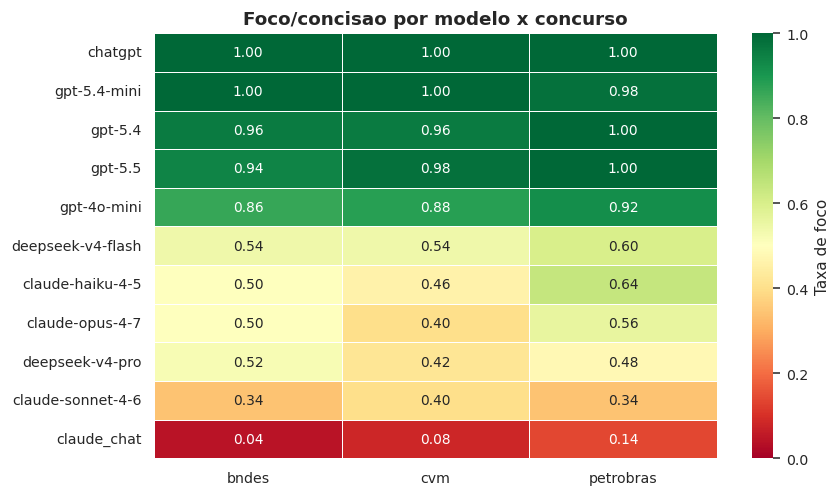

In [14]:
# Versao melhorada do heatmap usando seaborn.
data = pivot.drop(columns='media')
fig, ax = plt.subplots(figsize=(8, max(4.5, 0.42 * len(data))))
sns.heatmap(data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'Taxa de foco'}, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'fontsize': 9})
ax.set_title('Foco/concisao por modelo x concurso')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.5 Perguntas que mais induziram verbosidade

Quais perguntas, no agregado dos 11 modelos, tiveram mais respostas verbosas? Útil para discutir no TCC: certas perguntas (mais abertas, mais amplas) ativam o reflexo de "despejar tudo".

In [15]:
por_pergunta = (df.groupby(['concurso', 'batch', 'id', 'pergunta'])['score']
                  .agg(taxa_foco='mean', n_modelos='count')
                  .reset_index()
                  .sort_values('taxa_foco'))
print('Top 10 perguntas com MENOR taxa de foco (mais induziram verbosidade):')
por_pergunta.head(10)

Top 10 perguntas com MENOR taxa de foco (mais induziram verbosidade):


,concurso,batch,id,pergunta,taxa_foco,n_modelos
16,bndes,2,17,Existe possibilidade de impugnar o edital do concurso BNDES?,0.182,11
40,bndes,5,41,Como é composta a prova discursiva de Ciência de Dados no concurso BNDES?,0.182,11
17,bndes,2,18,Qual é o cargo/ênfase/perfil de Ciência de Dados no concurso BNDES?,0.273,11
90,cvm,5,41,Como é composta a prova discursiva de Ciência de Dados no concurso CVM?,0.273,11
48,bndes,5,49,Como o candidato deve se identificar no dia da prova do concurso BNDES?,0.364,11
9,bndes,1,10,O candidato precisa guardar o comprovante de inscrição ou pagamento do concu...,0.364,11
116,petrobras,2,17,Existe possibilidade de impugnar o edital do concurso PETROBRAS?,0.364,11
14,bndes,2,15,Qual horário de referência deve ser considerado pelo candidato no concurso B...,0.364,11
105,petrobras,1,6,Quem pode pedir isenção da taxa de inscrição do concurso PETROBRAS?,0.364,11
94,cvm,5,45,Como é calculada a nota final do concurso CVM para Ciência de Dados?,0.364,11


In [16]:
print('Top 10 perguntas com MAIOR taxa de foco (todos os modelos foram diretos):')
por_pergunta.tail(10).iloc[::-1]

Top 10 perguntas com MAIOR taxa de foco (todos os modelos foram diretos):


,concurso,batch,id,pergunta,taxa_foco,n_modelos
69,cvm,2,20,Quantas vagas imediatas existem para Ciência de Dados no concurso CVM?,1.000,11
113,petrobras,2,14,Em quais cidades ou locais as provas do concurso PETROBRAS serão realizadas?,1.000,11
53,cvm,1,4,Quais são as formas de pagamento da taxa de inscrição do concurso CVM?,1.000,11
147,petrobras,5,48,Qual tipo de caneta pode ser utilizado para realizar o concurso PETROBRAS?,0.909,11
149,petrobras,5,50,Quais cuidados o candidato deve ter com o cartão ou folha de respostas no co...,0.909,11
148,petrobras,5,49,Como o candidato deve se identificar no dia da prova do concurso PETROBRAS?,0.909,11
128,petrobras,3,29,O cargo de Ciência de Dados exige disponibilidade para viagens no concurso P...,0.909,11
137,petrobras,4,38,Qual é o critério mínimo de aprovação na prova objetiva do concurso PETROBRAS?,0.909,11
75,cvm,3,26,Qual escolaridade é exigida para concorrer à área de Ciência de Dados no con...,0.909,11
83,cvm,4,34,Quantas alternativas existem para as questões objetivas do concurso CVM?,0.909,11


### 4.6 Análise de justificativas

As justificativas escritas pelo avaliador descrevem *por que* uma resposta foi considerada verbosa. Padrões frequentes aqui viram material qualitativo para o TCC.

In [17]:
print('Justificativas mais frequentes em respostas verbosas (score=0):')
print(df[df['score'] == 0]['justificativa']
        .value_counts()
        .head(20)
        .to_string())

Justificativas mais frequentes em respostas verbosas (score=0):
justificativa
despejou pagamento, devolução e isenção sem pedir             7
despejou como solicitar e regras extras sem pedir             7
detalhou regras e procedimentos além do necessário            6
detalhou contrato e avaliações além do vínculo                6
despejou requisitos adicionais além do recorte pedido         6
despejou salário, jornada e detalhes além das atribuições     6
detalhou procedimentos e documentação além do necessário      5
despejou procedimento e detalhes além do pagamento            5
despejou cronograma e procedimentos sem pedir                 5
despejou pagamento, foto e processo sem pedir                 5
despejou alterações, taxas e regras além do necessário        5
despejou itens do dia da prova e detalhes extras sem pedir    5
despejou critérios de eliminação sem pedir                    4
despejou quem podia pedir e cronograma sem pedir              3
resposta longa demais para

In [18]:
print('Justificativas mais frequentes em respostas focadas (score=1):')
print(df[df['score'] == 1]['justificativa']
        .value_counts()
        .head(10)
        .to_string())

Justificativas mais frequentes em respostas focadas (score=1):
justificativa
respondeu o período com volume razoável                 36
respondeu o prazo com volume razoável                   21
respondeu o site com volume razoável                    19
respondeu a escolaridade com volume razoável            19
respondeu sim com volume razoável                       18
respondeu os locais com volume razoável                 18
respondeu as formas de pagamento com volume razoável    17
respondeu não com volume razoável                       16
respondeu vagas e cadastro com volume razoável          15
respondeu as atribuições com volume razoável            15


### 4.7 Variância entre batches do mesmo modelo

Mede consistência: um modelo é estável ou tem dias bons e ruins?

In [19]:
consistencia = (df.groupby(['modelo', 'concurso', 'batch'])['score']
                  .mean()
                  .reset_index()
                  .groupby('modelo')['score']
                  .agg(media='mean', desvio='std', n_batches='count')
                  .sort_values('desvio'))
print('Modelos por consistencia (menor desvio = mais estavel):')
consistencia

Modelos por consistencia (menor desvio = mais estavel):


,media,desvio,n_batches
modelo,,,
chatgpt,1.000,0.000,15
gpt-5.4-mini,0.993,0.026,15
gpt-5.4,0.973,0.046,15
gpt-5.5,0.973,0.059,15
gpt-4o-mini,0.887,0.125,15
deepseek-v4-flash,0.560,0.130,15
claude_chat,0.087,0.168,15
claude-opus-4-7,0.487,0.173,15
deepseek-v4-pro,0.473,0.194,15


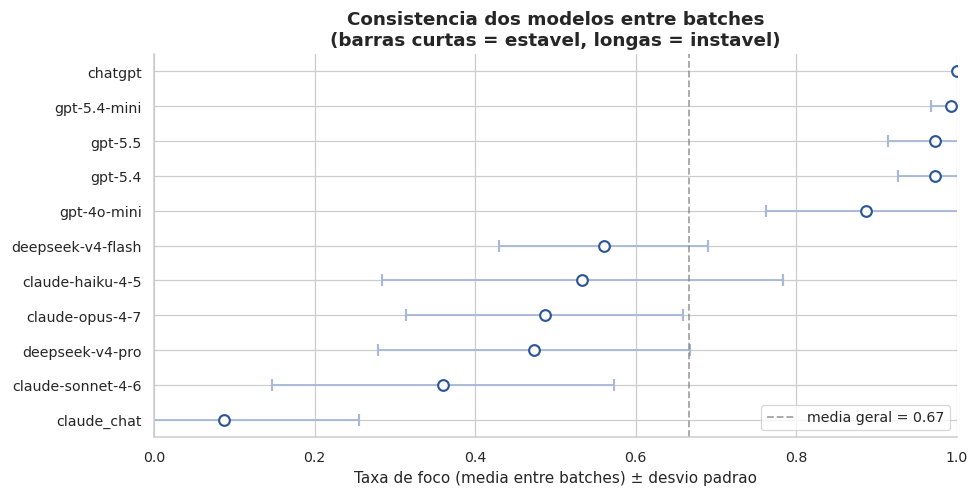

In [20]:
# Visualizacao: media com erro = desvio entre batches por modelo.
# Modelos mais a direita sao mais estaveis (menor desvio).
fig, ax = plt.subplots(figsize=(9, max(4.5, 0.42 * len(consistencia))))
cons_sorted = consistencia.sort_values('media')
y_pos = np.arange(len(cons_sorted))
ax.errorbar(cons_sorted['media'], y_pos, xerr=cons_sorted['desvio'],
            fmt='o', color='#2b5797', ecolor='#a8b8d8',
            capsize=4, markersize=7, markerfacecolor='white', markeredgewidth=1.4)
ax.set_yticks(y_pos)
ax.set_yticklabels(cons_sorted.index)
ax.axvline(df['score'].mean(), ls='--', color='gray', alpha=0.7,
           label=f'media geral = {df["score"].mean():.2f}')
ax.set_xlabel('Taxa de foco (media entre batches) ± desvio padrao')
ax.set_xlim(0, 1)
ax.set_title('Consistencia dos modelos entre batches\n(barras curtas = estavel, longas = instavel)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Analise quantitativa do tamanho das respostas (tokens)

A metrica de foco/concisao e binaria (0 ou 1), mas a verbosidade tem grandeza continua: tamanho da resposta.
Esta secao mede o tamanho de cada resposta em **tokens** (proxy universal via `cl100k_base`, o tokenizador
da familia GPT-4) e em **palavras**, e cruza essas medidas com o score atribuido pelo avaliador.

**Por que tokens, e nao caracteres?** Porque tokens sao a unidade de custo computacional e financeiro
de LLMs (latencia, preco da API, limite de contexto). Sao a metrica que importa em producao.

**Sobre o tokenizador.** Cada modelo tem o seu, mas usar onze tokenizadores diferentes em uma analise
comparativa introduziria mais ruido do que sinal. `cl100k_base` e adotado como **proxy unificado**:
ele aproxima razoavelmente o tamanho que um modelo da familia GPT-4 contaria, e mantem todas as
respostas no mesmo "regua".

### 5.1 Calcular tokens, palavras e caracteres

Adiciona as colunas `n_tokens`, `n_palavras` e `n_chars` ao DataFrame consolidado.

In [21]:
# Linhas sem resposta sao tratadas como zero tokens (e logadas se houver).
n_resp_nulas = df['resposta'].isna().sum()
if n_resp_nulas:
    print(f'AVISO: {n_resp_nulas} linhas com resposta nula. Serao contadas como 0 tokens.')

df['n_tokens'] = df['resposta'].fillna('').astype(str).apply(_count_tokens)
df['n_palavras'] = df['resposta'].fillna('').astype(str).str.split().str.len().fillna(0).astype(int)
df['n_chars'] = df['resposta'].fillna('').astype(str).str.len()

print(f'\nTokens: min={df.n_tokens.min()}, mediana={df.n_tokens.median():.0f}, '
      f'media={df.n_tokens.mean():.1f}, p90={df.n_tokens.quantile(0.9):.0f}, max={df.n_tokens.max()}')
print(f'Razao tokens/palavras (media): {(df.n_tokens / df.n_palavras.replace(0, np.nan)).mean():.2f}')


Tokens: min=19, mediana=199, media=265.4, p90=550, max=2272
Razao tokens/palavras (media): 2.04


### 5.2 Tabela mestre: tokens por modelo x indice de concisao

Esta e a tabela central do estudo. Para cada modelo, mostra:
- `taxa_foco`: indice de concisao (proporcao de respostas com score=1)
- `tokens_media` e `tokens_mediana`: tamanho tipico da resposta
- `tokens_p90`: percentil 90 (cauda longa — quao "infladas" ficam as respostas piores)
- `palavras_media`: para leitores nao familiarizados com tokens
- `n_total`: numero de respostas avaliadas

A hipotese e que **taxa_foco e tokens_media estao inversamente correlacionados**: modelos que
respondem em menos tokens tendem a ser julgados mais focados.

In [22]:
tabela_modelo = (
    df.groupby('modelo')
      .agg(
          taxa_foco=('score', 'mean'),
          tokens_media=('n_tokens', 'mean'),
          tokens_mediana=('n_tokens', 'median'),
          tokens_p90=('n_tokens', lambda x: x.quantile(0.9)),
          palavras_media=('n_palavras', 'mean'),
          n_total=('score', 'count'),
      )
      .sort_values('taxa_foco', ascending=False)
      .round({'taxa_foco': 3, 'tokens_media': 1, 'tokens_mediana': 1,
              'tokens_p90': 1, 'palavras_media': 1})
)
tabela_modelo

,taxa_foco,tokens_media,tokens_mediana,tokens_p90,palavras_media,n_total
modelo,,,,,,
chatgpt,1.000,74.700,65.500,138.200,38.500,150
gpt-5.4-mini,0.993,119.600,107.500,206.100,60.500,150
gpt-5.4,0.973,128.700,110.000,247.700,65.500,150
gpt-5.5,0.973,138.400,122.500,248.500,66.700,150
gpt-4o-mini,0.887,170.300,150.500,299.200,91.100,150
deepseek-v4-flash,0.560,305.100,274.500,539.200,144.200,150
claude-haiku-4-5,0.533,271.400,256.000,415.500,134.000,150
claude-opus-4-7,0.487,313.800,276.000,567.400,148.400,150
deepseek-v4-pro,0.473,344.200,300.000,584.200,168.100,150


In [23]:
# Versao com cores para facilitar leitura (taxa de foco verde-amarelo-vermelho,
# tokens em vermelho-amarelo-verde invertido, pois mais tokens = pior concisao).
tabela_modelo.style.background_gradient(
    subset=['taxa_foco'], cmap='RdYlGn', vmin=0, vmax=1
).background_gradient(
    subset=['tokens_media', 'tokens_mediana', 'tokens_p90', 'palavras_media'],
    cmap='RdYlGn_r'
).format({
    'taxa_foco': '{:.3f}',
    'tokens_media': '{:.1f}',
    'tokens_mediana': '{:.0f}',
    'tokens_p90': '{:.0f}',
    'palavras_media': '{:.1f}',
}).set_caption('Tokens medios por modelo x indice de concisao')

,taxa_foco,tokens_media,tokens_mediana,tokens_p90,palavras_media,n_total
modelo,,,,,,
chatgpt,1.000,74.7,66,138,38.5,150
gpt-5.4-mini,0.993,119.6,108,206,60.5,150
gpt-5.4,0.973,128.7,110,248,65.5,150
gpt-5.5,0.973,138.4,122,248,66.7,150
gpt-4o-mini,0.887,170.3,150,299,91.1,150
deepseek-v4-flash,0.560,305.1,274,539,144.2,150
claude-haiku-4-5,0.533,271.4,256,416,134.0,150
claude-opus-4-7,0.487,313.8,276,567,148.4,150
deepseek-v4-pro,0.473,344.2,300,584,168.1,150


### 5.3 Tamanho medio da resposta x indice de concisao

Cada ponto e um modelo. Eixo x: tokens medios por resposta. Eixo y: taxa de foco.

Se a correlacao for forte e negativa, a leitura para o TCC e direta: **o ranking de foco e
essencialmente um ranking de brevidade**. Quanto mais um modelo "fala", menor a chance de o
avaliador considerar a resposta focada.

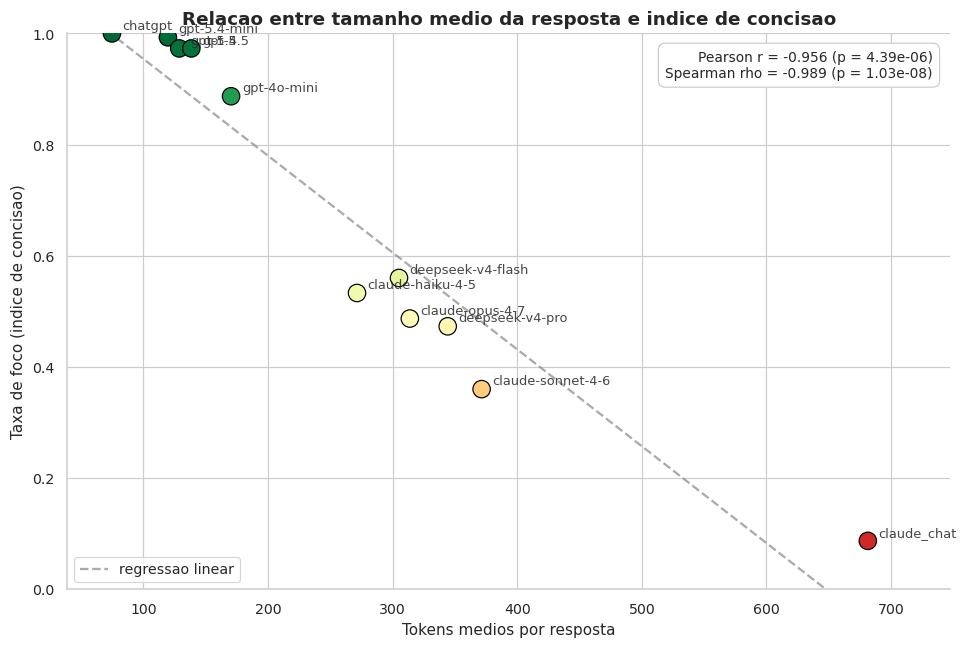

In [24]:
x = tabela_modelo['tokens_media']
y = tabela_modelo['taxa_foco']
r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(9, 6))
coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min() * 0.95, x.max() * 1.05, 100)
ax.plot(xs, np.polyval(coef, xs), '--', color='#888', lw=1.5, alpha=0.7,
        label='regressao linear')
ax.scatter(x, y, s=130, c=y, cmap='RdYlGn', vmin=0, vmax=1,
           edgecolors='black', linewidths=0.8, zorder=3)
for modelo, row in tabela_modelo.iterrows():
    ax.annotate(modelo, (row['tokens_media'], row['taxa_foco']),
                xytext=(7, 3), textcoords='offset points', fontsize=8.5, alpha=0.85)
ax.set_xlabel('Tokens medios por resposta')
ax.set_ylabel('Taxa de foco (indice de concisao)')
ax.set_title('Relacao entre tamanho medio da resposta e indice de concisao')
ax.text(0.98, 0.97,
        f'Pearson r = {r_p:.3f} (p = {p_p:.2e})\nSpearman rho = {r_s:.3f} (p = {p_s:.2e})',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#ccc'),
        fontsize=9)
ax.set_ylim(0, 1)
ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

### 5.4 Distribuicao de tokens por modelo (boxplot)

A media esconde a cauda. O boxplot mostra a forma da distribuicao de cada modelo:
caixa = quartis (Q1-Q3), linha = mediana, pontos = outliers. Escala log no eixo x porque
respostas verbosas chegam a ordens de grandeza acima das focadas.

A cor de cada caixa codifica a taxa de foco do modelo (verde = consistente, vermelho = problemático),
ligando visualmente *brevidade* a *concisao*.

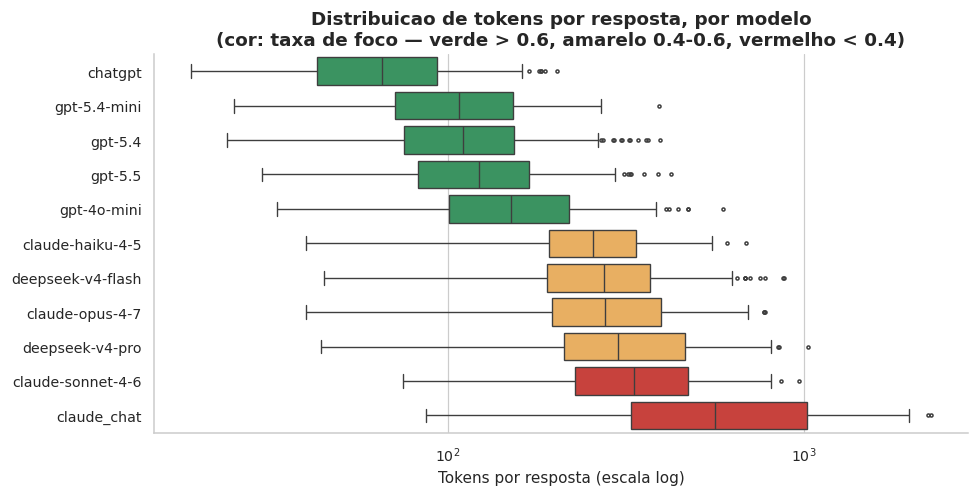

In [25]:
ordem = df.groupby('modelo')['n_tokens'].median().sort_values().index.tolist()
foco_por_modelo = df.groupby('modelo')['score'].mean()
cores_box = ['#2ca25f' if foco_por_modelo[m] > 0.6
             else '#feb24c' if foco_por_modelo[m] > 0.4
             else '#de2d26' for m in ordem]

fig, ax = plt.subplots(figsize=(9, max(4.5, 0.42 * len(ordem))))
sns.boxplot(data=df, y='modelo', x='n_tokens', order=ordem,
            hue='modelo', palette=dict(zip(ordem, cores_box)),
            legend=False, fliersize=2, linewidth=0.9, ax=ax)
ax.set_xlabel('Tokens por resposta (escala log)')
ax.set_ylabel('')
ax.set_xscale('log')
ax.set_title('Distribuicao de tokens por resposta, por modelo\n'
             '(cor: taxa de foco — verde > 0.6, amarelo 0.4-0.6, vermelho < 0.4)')
plt.tight_layout()
plt.show()

### 5.5 Tokens em respostas focadas vs verbosas

Compara diretamente os dois grupos definidos pelo score. Dois paineis:

1. **Histograma sobreposto** (esquerda): mostra onde cada grupo concentra massa.
2. **ECDF — funcao de distribuicao acumulada empirica** (direita): mostra explicitamente quanto
   uma distribuicao "domina" a outra, sem o ruido visual de binagem.

**Estatisticas usadas.** Como a distribuicao de tokens e fortemente assimetrica (cauda longa
a direita), **media + teste-t nao sao apropriados**. Use:
- **Mann-Whitney U** (teste nao parametrico de localizacao);
- **Cliff's δ** como tamanho de efeito nao parametrico: δ varia de -1 a +1; |δ| > 0.474 = grande.

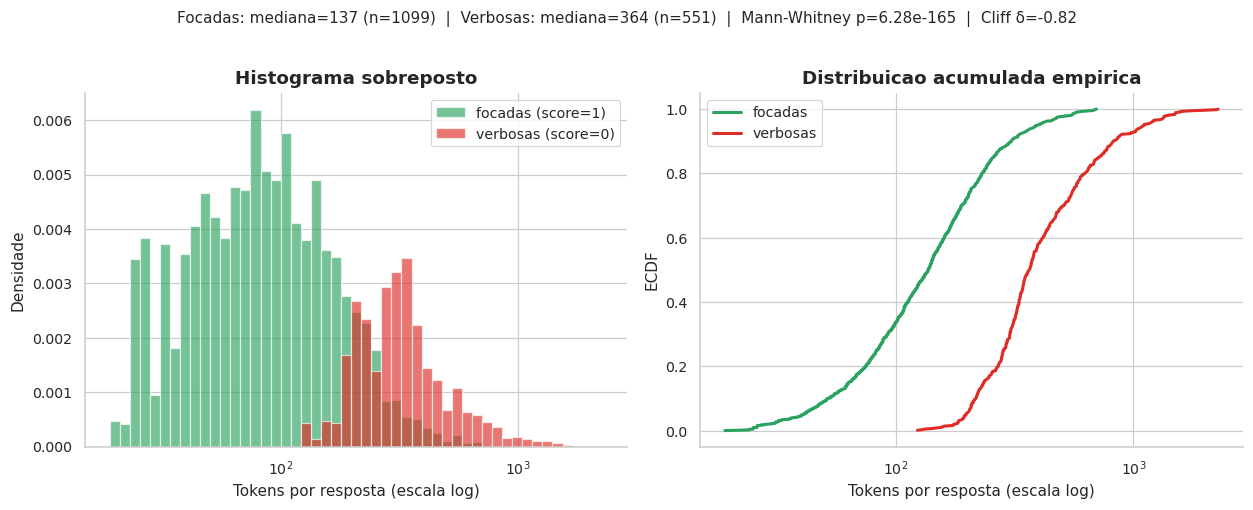


Interpretacao do delta: grande


In [26]:
def cliffs_delta(a, b):
    """Tamanho de efeito nao parametrico, baseado em ranks (vetorizado)."""
    from scipy.stats import rankdata
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    combined = np.concatenate([a, b])
    ranks = rankdata(combined)
    ua = ranks[:len(a)].sum() - len(a) * (len(a) + 1) / 2
    return 2 * ua / (len(a) * len(b)) - 1

tok_focadas = df[df.score == 1]['n_tokens']
tok_verbosas = df[df.score == 0]['n_tokens']

u_stat, p_val = stats.mannwhitneyu(tok_focadas, tok_verbosas, alternative='less')
delta = cliffs_delta(tok_focadas.values, tok_verbosas.values)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

ax = axes[0]
bins = np.logspace(np.log10(max(df.n_tokens.min(), 1)),
                   np.log10(df.n_tokens.max()), 50)
ax.hist(tok_focadas, bins=bins, alpha=0.65, label='focadas (score=1)',
        color='#2ca25f', density=True)
ax.hist(tok_verbosas, bins=bins, alpha=0.65, label='verbosas (score=0)',
        color='#de2d26', density=True)
ax.set_xscale('log')
ax.set_xlabel('Tokens por resposta (escala log)')
ax.set_ylabel('Densidade')
ax.set_title('Histograma sobreposto')
ax.legend()

ax = axes[1]
for s, label, color in [(1, 'focadas', '#2ca25f'), (0, 'verbosas', '#de2d26')]:
    vals = np.sort(df[df.score == s]['n_tokens'].values)
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf, label=label, color=color, lw=2)
ax.set_xscale('log')
ax.set_xlabel('Tokens por resposta (escala log)')
ax.set_ylabel('ECDF')
ax.set_title('Distribuicao acumulada empirica')
ax.legend()

fig.suptitle(
    f'Focadas: mediana={tok_focadas.median():.0f} (n={len(tok_focadas)})  |  '
    f'Verbosas: mediana={tok_verbosas.median():.0f} (n={len(tok_verbosas)})  |  '
    f'Mann-Whitney p={p_val:.2e}  |  Cliff δ={delta:.2f}',
    fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nInterpretacao do delta: {"grande" if abs(delta) > 0.474 else "medio" if abs(delta) > 0.33 else "pequeno" if abs(delta) > 0.147 else "negligenciavel"}')

### 5.6 Tokens medios por modelo x concurso (heatmap)

Mostra se o efeito do tamanho da resposta e estavel entre os concursos. Se um modelo
"infla" muito em CVM e nao em BNDES, isso aparece aqui como heterogeneidade horizontal.

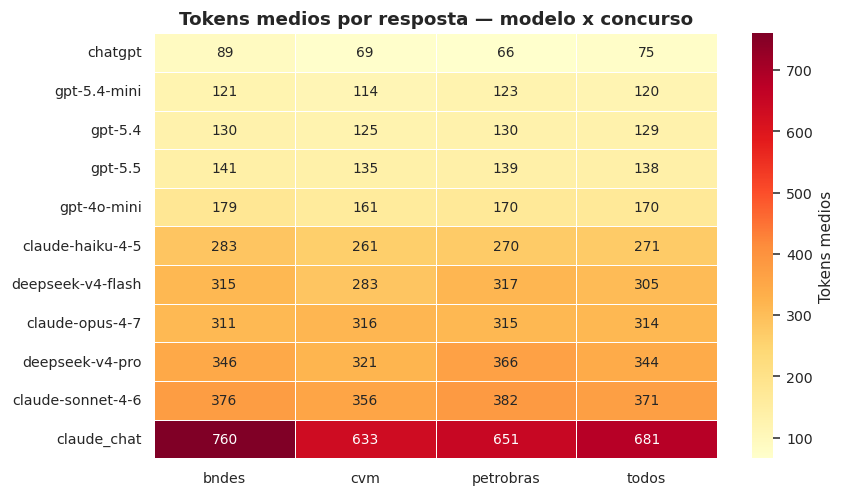

In [27]:
pivot_tok = df.pivot_table(index='modelo', columns='concurso',
                           values='n_tokens', aggfunc='mean')
pivot_tok['todos'] = pivot_tok.mean(axis=1)
pivot_tok = pivot_tok.sort_values('todos')

fig, ax = plt.subplots(figsize=(8, max(4.5, 0.42 * len(pivot_tok))))
sns.heatmap(pivot_tok, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Tokens medios'}, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'fontsize': 9})
ax.set_title('Tokens medios por resposta — modelo x concurso')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 5.8 Comparacao entre modelos com intervalos de confianca (forest plot)

Comparar taxas pontuais (`0.84 vs 0.79`) sem intervalo de confianca e ruim para um TCC: o leitor
nao sabe se a diferenca e robusta. Aqui cada modelo aparece como ponto com **IC 95% de Wilson**,
que e o intervalo apropriado para proporcoes (mais bem-comportado que o normal-aproximado quando
n e moderado ou p esta perto de 0 ou 1).

Se dois ICs nao se cruzam, ha boa evidencia de diferenca real entre os modelos.

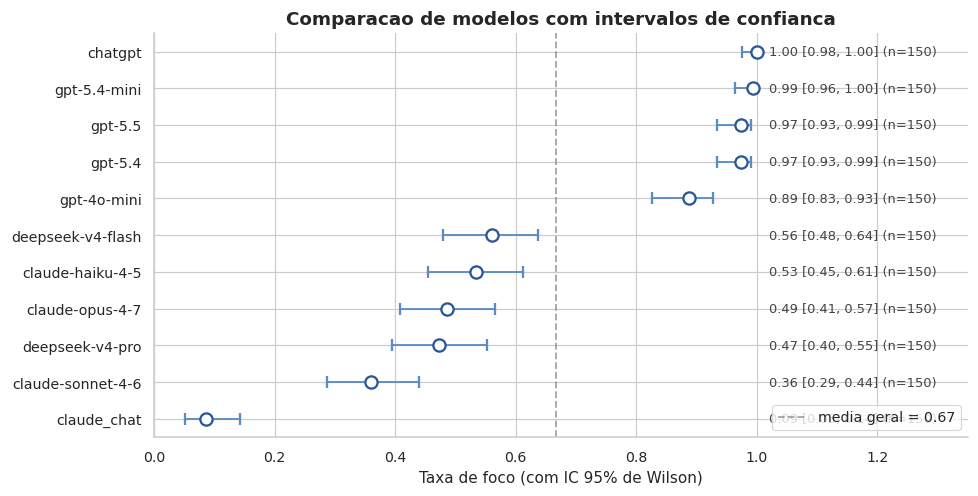

In [29]:
def wilson_ci(k: int, n: int, z: float = 1.96):
    """Intervalo de confianca de Wilson para proporcao k/n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    margem = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centro - margem, centro + margem)

ic_rows = []
for modelo, grp in df.groupby('modelo'):
    k = int(grp.score.sum()); n = len(grp)
    lo, hi = wilson_ci(k, n)
    ic_rows.append({'modelo': modelo, 'taxa_foco': k/n,
                    'lo': lo, 'hi': hi, 'n': n})
ic_df = pd.DataFrame(ic_rows).sort_values('taxa_foco', ascending=True)
media_geral = df.score.mean()

fig, ax = plt.subplots(figsize=(9, max(4.5, 0.42 * len(ic_df))))
ys = np.arange(len(ic_df))
ax.errorbar(ic_df.taxa_foco, ys,
            xerr=[ic_df.taxa_foco - ic_df.lo, ic_df.hi - ic_df.taxa_foco],
            fmt='o', color='#2b5797', ecolor='#5a8bc4', capsize=4, markersize=8,
            markerfacecolor='white', markeredgewidth=1.5)
ax.axvline(media_geral, ls='--', color='gray', alpha=0.7,
           label=f'media geral = {media_geral:.2f}')
ax.set_yticks(ys); ax.set_yticklabels(ic_df.modelo)
ax.set_xlabel('Taxa de foco (com IC 95% de Wilson)')
ax.set_title('Comparacao de modelos com intervalos de confianca')
ax.set_xlim(0, 1.35)
ax.legend(loc='lower right')

for i, row in enumerate(ic_df.itertuples()):
    ax.text(1.02, i, f'{row.taxa_foco:.2f} [{row.lo:.2f}, {row.hi:.2f}] (n={row.n})',
            va='center', fontsize=8.5, color='#444')
plt.tight_layout()
plt.show()

### 5.9 Tokens em focadas vs verbosas, por modelo

Outra forma de olhar 5.5: agora separado por modelo. Para cada modelo, qual a mediana de
tokens das suas respostas julgadas focadas, e qual a das julgadas verbosas? O **gap**
verbosa-focada e em si um indicador interessante — modelos com gap pequeno tem dificuldade
de "se conter" mesmo quando a resposta e considerada boa.

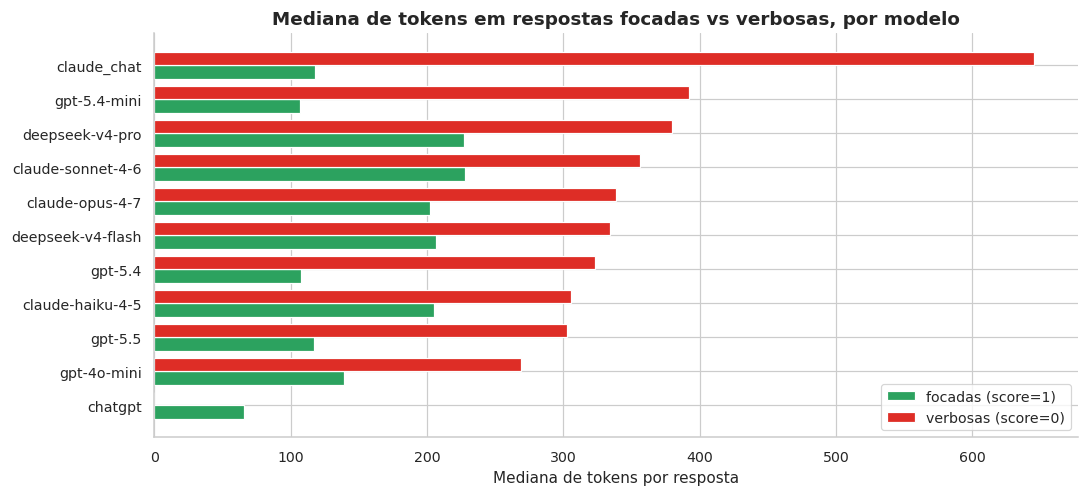


Gap entre verbosas e focadas (mediana, em tokens):
score              focadas  verbosas     gap
modelo                                      
claude_chat        118.000   645.000 527.000
gpt-5.4-mini       107.000   392.000 285.000
gpt-5.4            108.000   324.000 216.000
gpt-5.5            117.000   303.000 186.000
deepseek-v4-pro    227.000   380.000 153.000
claude-opus-4-7    202.000   339.000 137.000
gpt-4o-mini        139.000   269.000 130.000
claude-sonnet-4-6  228.000   356.000 128.000
deepseek-v4-flash  206.000   334.000 128.000
claude-haiku-4-5   205.000   306.000 100.000
chatgpt             66.000     0.000 -66.000


In [30]:
agg_fv = (
    df.groupby(['modelo', 'score'])['n_tokens'].median()
      .unstack()
      .rename(columns={0: 'verbosas', 1: 'focadas'})
)
# Para ordenar com seguranca, mesmo que algum modelo nao tenha exemplo de um dos lados:
agg_fv = agg_fv.fillna(0).sort_values('verbosas')

fig, ax = plt.subplots(figsize=(10, max(4.5, 0.42 * len(agg_fv))))
y_pos = np.arange(len(agg_fv))
h = 0.4
ax.barh(y_pos - h/2, agg_fv['focadas'], h,
        label='focadas (score=1)', color='#2ca25f')
ax.barh(y_pos + h/2, agg_fv['verbosas'], h,
        label='verbosas (score=0)', color='#de2d26')
ax.set_yticks(y_pos); ax.set_yticklabels(agg_fv.index)
ax.set_xlabel('Mediana de tokens por resposta')
ax.set_title('Mediana de tokens em respostas focadas vs verbosas, por modelo')
ax.legend()
plt.tight_layout()
plt.show()

# Gap absoluto verbosa - focada
agg_fv['gap'] = agg_fv['verbosas'] - agg_fv['focadas']
print('\nGap entre verbosas e focadas (mediana, em tokens):')
print(agg_fv.sort_values('gap', ascending=False)[['focadas', 'verbosas', 'gap']].round(0))

### 5.10 Tabela consolidada para o TCC

Tabela final pronta para inserir no texto: junta taxa de foco com IC de Wilson, tokens medios,
tokens medianos e amostra. Exportada em CSV e em LaTeX para facilitar uso no documento.

In [31]:
tabela_tcc = tabela_modelo.copy()
tabela_tcc = tabela_tcc.merge(
    ic_df.set_index('modelo')[['lo', 'hi']],
    left_index=True, right_index=True,
)
tabela_tcc['ic95'] = tabela_tcc.apply(
    lambda r: f'[{r["lo"]:.2f}, {r["hi"]:.2f}]', axis=1)
tabela_tcc = tabela_tcc[
    ['taxa_foco', 'ic95', 'tokens_media', 'tokens_mediana', 'tokens_p90',
     'palavras_media', 'n_total']
].rename(columns={
    'taxa_foco': 'Taxa de foco',
    'ic95': 'IC 95% Wilson',
    'tokens_media': 'Tokens (media)',
    'tokens_mediana': 'Tokens (mediana)',
    'tokens_p90': 'Tokens (p90)',
    'palavras_media': 'Palavras (media)',
    'n_total': 'n',
})
tabela_tcc

,Taxa de foco,IC 95% Wilson,Tokens (media),Tokens (mediana),Tokens (p90),Palavras (media),n
modelo,,,,,,,
chatgpt,1.000,"[0.98, 1.00]",74.700,65.500,138.200,38.500,150
gpt-5.4-mini,0.993,"[0.96, 1.00]",119.600,107.500,206.100,60.500,150
gpt-5.4,0.973,"[0.93, 0.99]",128.700,110.000,247.700,65.500,150
gpt-5.5,0.973,"[0.93, 0.99]",138.400,122.500,248.500,66.700,150
gpt-4o-mini,0.887,"[0.83, 0.93]",170.300,150.500,299.200,91.100,150
deepseek-v4-flash,0.560,"[0.48, 0.64]",305.100,274.500,539.200,144.200,150
claude-haiku-4-5,0.533,"[0.45, 0.61]",271.400,256.000,415.500,134.000,150
claude-opus-4-7,0.487,"[0.41, 0.57]",313.800,276.000,567.400,148.400,150
deepseek-v4-pro,0.473,"[0.40, 0.55]",344.200,300.000,584.200,168.100,150


In [32]:
# Exporta a tabela final em CSV e LaTeX
out_tab_csv = NOTEBOOK_DIR / 'tabela_tcc_tokens_foco.csv'
out_tab_tex = NOTEBOOK_DIR / 'tabela_tcc_tokens_foco.tex'
tabela_tcc.to_csv(out_tab_csv)

# LaTeX com formatacao adequada — pandas >= 1.0 tem to_latex
try:
    latex_str = tabela_tcc.to_latex(
        float_format='%.2f',
        caption='Indice de concisao (taxa de foco) e tamanho medio da resposta por modelo. '
                'IC 95\\% calculado pelo metodo de Wilson para proporcoes.',
        label='tab:tokens_foco',
        position='ht',
    )
    out_tab_tex.write_text(latex_str, encoding='utf-8')
    print(f'Salvo: {out_tab_csv.name}')
    print(f'Salvo: {out_tab_tex.name}')
except Exception as e:
    print(f'CSV salvo, mas LaTeX falhou: {e}')

Salvo: tabela_tcc_tokens_foco.csv
Salvo: tabela_tcc_tokens_foco.tex


## 6. Exportar consolidado

Salva o DataFrame consolidado (ja com as colunas `n_tokens`, `n_palavras`, `n_chars` adicionadas
em 5.1) em `consolidado_foco_concisao.csv` e `.xlsx` para uso fora do notebook.

In [33]:
out_csv = NOTEBOOK_DIR / 'consolidado_foco_concisao.csv'
out_xlsx = NOTEBOOK_DIR / 'consolidado_foco_concisao.xlsx'
df.to_csv(out_csv, index=False)
df.to_excel(out_xlsx, index=False)
print(f'Salvo: {out_csv.name}')
print(f'Salvo: {out_xlsx.name}')

Salvo: consolidado_foco_concisao.csv
Salvo: consolidado_foco_concisao.xlsx
